In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
from pathlib import Path
from functools import cached_property
from dataclasses import dataclass
import numpy as np
from rasterio.warp import transform_bounds
from datetime import datetime, date
import joblib
from tqdm import tqdm
from scipy.ndimage import zoom

import rasterio
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds as window_from_bounds


In [3]:
from utils.constants import SENTINEL_SCENES_FOLDERPATH, SILVER_FOLDERPATH
from utils.site import Site
from utils.stac_item import STACItem

In [46]:
# Load sites
sites = joblib.load(SILVER_FOLDERPATH / "sites.pkl")
print(f"Loaded {len(sites)} sites")

Loaded 155 sites


In [5]:
# Load stac_items
stac_items = joblib.load(SILVER_FOLDERPATH / "stac_items.joblib")

# Only keep downloaded STAC items
stac_items = [e for e in stac_items if (SENTINEL_SCENES_FOLDERPATH / e.id / "stac_item.joblib").exists()]
bboxes = list(set([tuple(e.bbox) for e in stac_items]))

print(f"# downloaded STAC items: {len(stac_items)}")
print(f"- covering {len(bboxes)} unique bboxes.")

# downloaded STAC items: 48
- covering 48 unique bboxes.


In [50]:
# Figure out on which STAC items each site appears
allowed_ids = set([e.id for e in stac_items])
site_name_to_scene_ids = {}
for s in tqdm(sites, total=len(sites)):
    found_scene_ids = STACItem.find_from_bbox(s.bbox)

    # Only keep selected ones
    site_name_to_scene_ids[s.name] = [e for e in found_scene_ids if e in allowed_ids]

100%|█████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:07<00:00, 22.12it/s]


In [51]:
@dataclass
class CroppedSnapshot:
    rgb_re_nir_swir: np.ndarray  # RGB RE NIR SWIR
    bounds: rasterio.coords.BoundingBox
    crs: rasterio.CRS

    @property
    def red(self) -> np.ndarray:
        return self.rgb_re_nir_swir[:, :, 0]

    @property
    def green(self) -> np.ndarray:
        return self.rgb_re_nir_swir[:, :, 1]

    @property
    def blue(self) -> np.ndarray:
        return self.rgb_re_nir_swir[:, :, 2]

    @property
    def red_edge(self) -> np.ndarray:
        return self.rgb_re_nir_swir[:, :, 3]

    @property
    def nir(self) -> np.ndarray:
        return self.rgb_re_nir_swir[:, :, 4]

    @property
    def swir(self) -> np.ndarray:
        return self.rgb_re_nir_swir[:, :, 5]

    @property
    def ndvi(self) -> np.ndarray:
        """Normalized Difference Vegetation Index"""
        return (self.nir - self.red) / (self.nir + self.red)

    @property
    def tci(self) -> np.ndarray:
        """Triangular Chlorophyll Index"""
        return 1.2 * (self.red_edge - self.green) - 1.5 * (self.red - self.green) * np.sqrt(self.red_edge / self.red)

    @cached_property
    def processed_rgb(self) -> np.ndarray:
        """Normalized & Gamma-corrected RGB."""
        # Normalize each band
        red = (self.red - np.nanmin(self.red)) / (np.nanmax(self.red) - np.nanmin(self.red))
        green = (self.green - np.nanmin(self.green)) / (np.nanmax(self.green) - np.nanmin(self.green))
        blue = (self.blue - np.nanmin(self.blue)) / (np.nanmax(self.blue) - np.nanmin(self.blue))

        # Brighten
        gamma = 2.5  # Hand-picked so that it looks nice
        red = np.power(red, 1 / gamma)
        green = np.power(green, 1 / gamma)
        blue = np.power(blue, 1 / gamma)

        return np.dstack((red, green, blue))

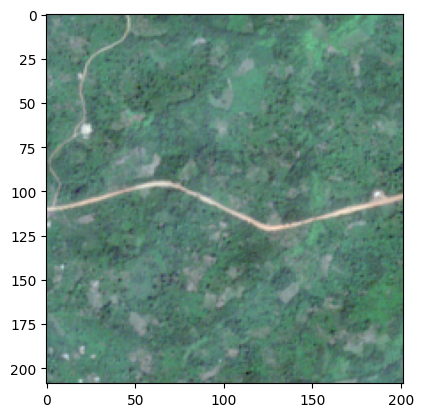

In [52]:
def load_crop(tif_path: Path, bbox_wgs84: tuple[float, float, float, float], padding_m: float) -> np.ndarray:
    """Loads a subset of a raster around a WGS84 bbox, with added padding in meters.
    
    Args:
        tif_path: Path to the raster file.
        bbox_wgs84: Tuple of (min_lon, min_lat, max_lon, max_lat).
        padding_m: Padding to add in all directions, in meters.
        
    Returns:
        data: The cropped numpy array.
        transform: The affine transform for the new cropped image.
    """
    min_lon, min_lat, max_lon, max_lat = bbox_wgs84

    with rasterio.open(tif_path) as src:
        # Project the WGS84 bbox into the raster's native CRS
        minx, miny, maxx, maxy = transform_bounds("EPSG:4326", src.crs, min_lon, min_lat, max_lon, max_lat)

        # Add padding in meters
        unit = src.crs.linear_units
        if unit not in ["metre", "meter"]:
            raise ValueError()
            
        minx -= padding_m
        miny -= padding_m
        maxx += padding_m
        maxy += padding_m

        # Convert the spatial bounding box into a pixel/array Window
        window = window_from_bounds(minx, miny, maxx, maxy, transform=src.transform)

        # Read the data within that window
        # boundless=True pads the array with fill_values if padded bbox extends beyond the actual edges of the raster image.
        data = src.read(1, window=window, boundless=True, fill_value=src.nodata)

        return data

def load_crop_from_id(scene_id: str, bbox_wgs84: tuple[float, float, float, float], padding_m: float) -> "CroppedSnapshot":
    """Load all .tif from scene ID."""

    # Load each raster in their .tif
    p = SENTINEL_SCENES_FOLDERPATH / scene_id
    red = load_crop(p / f"{p.name}_red.tif", bbox_wgs84, padding_m)
    green = load_crop(p / f"{p.name}_green.tif", bbox_wgs84, padding_m)
    blue = load_crop(p / f"{p.name}_blue.tif", bbox_wgs84, padding_m)
    red_edge = load_crop(p / f"{p.name}_rededge1.tif", bbox_wgs84, padding_m)
    nir = load_crop(p / f"{p.name}_nir.tif", bbox_wgs84, padding_m)
    swir = load_crop(p / f"{p.name}_swir22.tif", bbox_wgs84, padding_m)

    # Calculate exact zoom factors to match the 10m 'red' band shape perfectly
    re_zoom_y = red.shape[0] / red_edge.shape[0]
    re_zoom_x = red.shape[1] / red_edge.shape[1]
    red_edge = zoom(red_edge, zoom=(re_zoom_y, re_zoom_x), order=1)

    swir_zoom_y = red.shape[0] / swir.shape[0]
    swir_zoom_x = red.shape[1] / swir.shape[1]
    swir = zoom(swir, zoom=(swir_zoom_y, swir_zoom_x), order=1)

    rgb_re_nir_swir = np.dstack((red, green, blue, red_edge, nir, swir)).astype("float32")

    # Figure out bounds and crs using the 10m 'red' band as the spatial reference
    with rasterio.open(p / f"{p.name}_red.tif") as src:
        crs = src.crs
        min_lon, min_lat, max_lon, max_lat = bbox_wgs84
        
        # Recalculate padded coordinates
        minx, miny, maxx, maxy = transform_bounds("EPSG:4326", crs, min_lon, min_lat, max_lon, max_lat)
        minx -= padding_m
        miny -= padding_m
        maxx += padding_m
        maxy += padding_m
        
        # Calculate the pixel-snapped bounding box
        window = window_from_bounds(minx, miny, maxx, maxy, transform=src.transform)
        bounds = src.window_bounds(window)
        
    return CroppedSnapshot(rgb_re_nir_swir=rgb_re_nir_swir, bounds=bounds, crs=crs)

cs = load_crop_from_id("S2A_30NYM_20200102_0_L2A", sites[0].bbox, 1000)
plt.imshow(cs.processed_rgb)

In [55]:
site_name_to_crops = {}
for site in tqdm(sites, total=len(sites)):
    scene_ids = site_name_to_scene_ids[site.name]

    crops = []
    for scene_id in scene_ids:
        crop = load_crop_from_id(scene_id, site.bbox, padding_m=100)
        crops.append(crop)

    site_name_to_crops[site.name] = crops

    break

  0%|                                                                                                       | 0/155 [00:00<?, ?it/s]


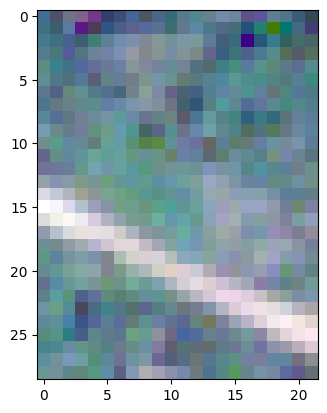

In [58]:
plt.imshow(site_name_to_crops["AC01"][4].processed_rgb)

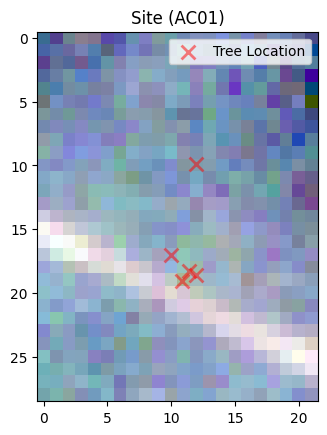

In [75]:
def plot_site_over_crop(site, cropped_snapshot):
    # 1. Project the WGS84 (lon, lat) point into the cropped image's native CRS
    lats = [lat for lat, _ in site.lat_lons]
    lons = [lon for _, lon in site.lat_lons]
    xs, ys = warp_transform("EPSG:4326", cropped_snapshot.crs, lons, lats)
    
    # 2. Reconstruct the affine transform for the cropped array
    minx, miny, maxx, maxy = cropped_snapshot.bounds
    height, width = cropped_snapshot.processed_rgb.shape[:2]
    img_transform = from_bounds(minx, miny, maxx, maxy, width, height)
    
    # 3. Convert the projected spatial coordinates to pixel coordinates (col, row)
    # FIX: Loop through each (x, y) pair and apply the inverse transform individually
    cols, rows = zip(*[~img_transform * (x, y) for x, y in zip(xs, ys)])
    
    # 4. Plot the image and the points
    plt.imshow(cropped_snapshot.processed_rgb)
    
    # Plot using the calculated pixel coordinates
    plt.scatter(cols, rows, color="red", marker="x", alpha=0.5, s=100, linewidths=2, label="Tree Location")
    
    plt.legend()
    plt.title(f"Site ({site.name})")    
    plt.show()
    
plot_site_over_crop(site, site_name_to_crops[site.name][0])

In [34]:
s = [e for e in sites if e.name == "KU06"][0]

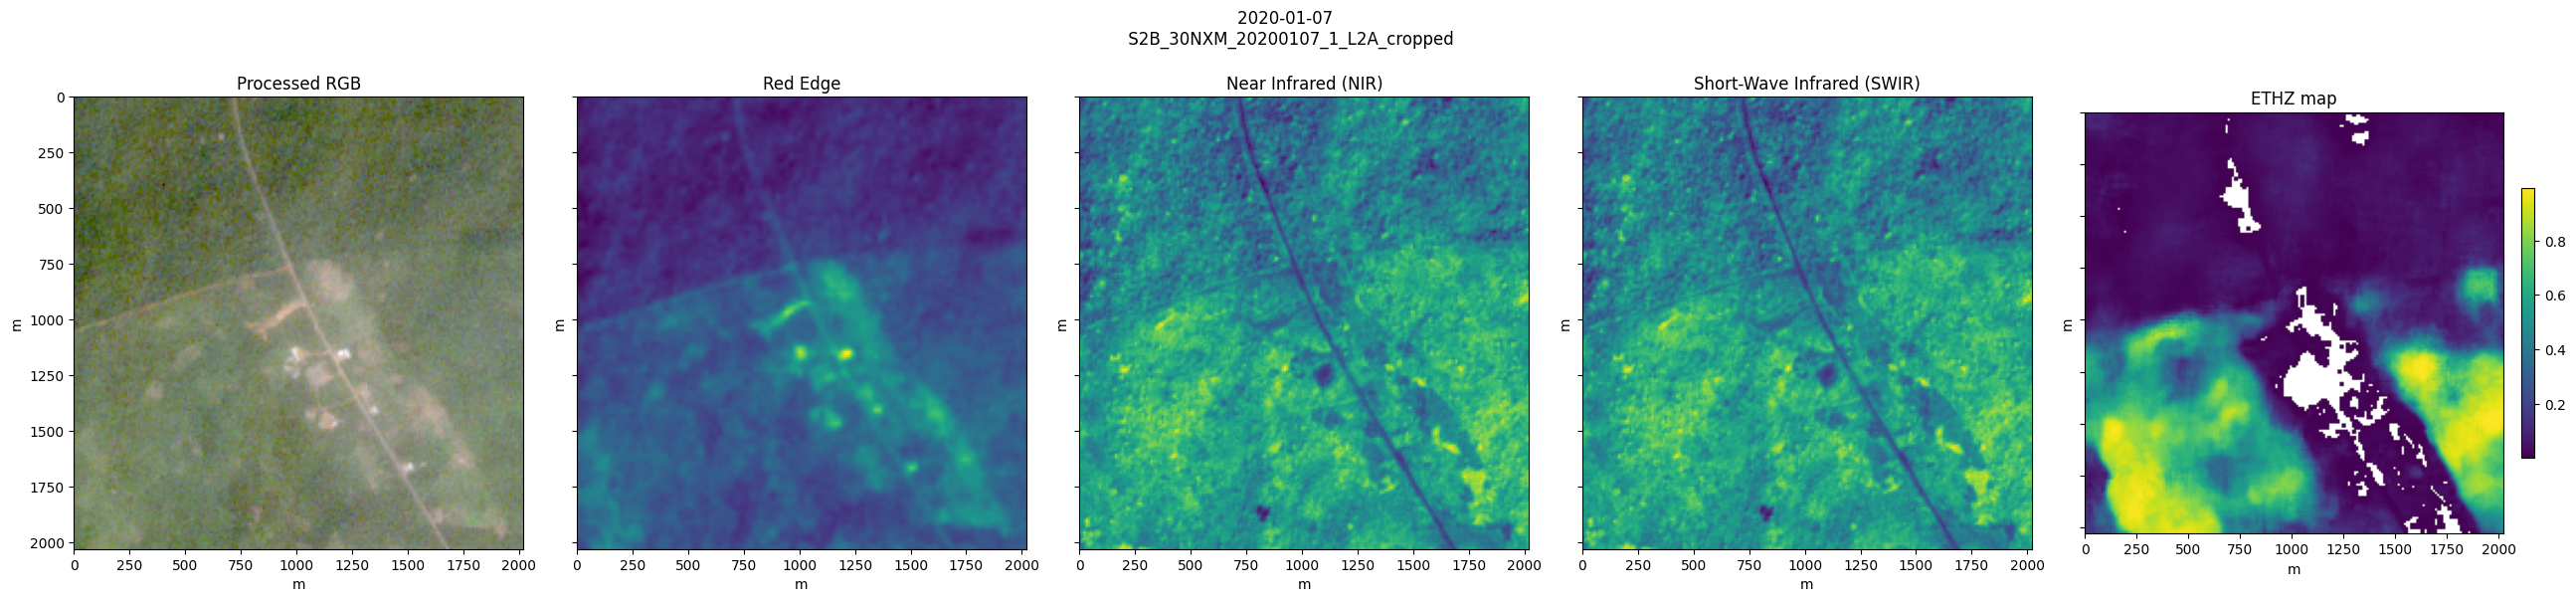

In [35]:
ss = s.sentinel_scenes[0]
ss.plot([(lon, lat) for lat, lon in s.lat_lons], padding_m=1000, plot_scale=2.0)

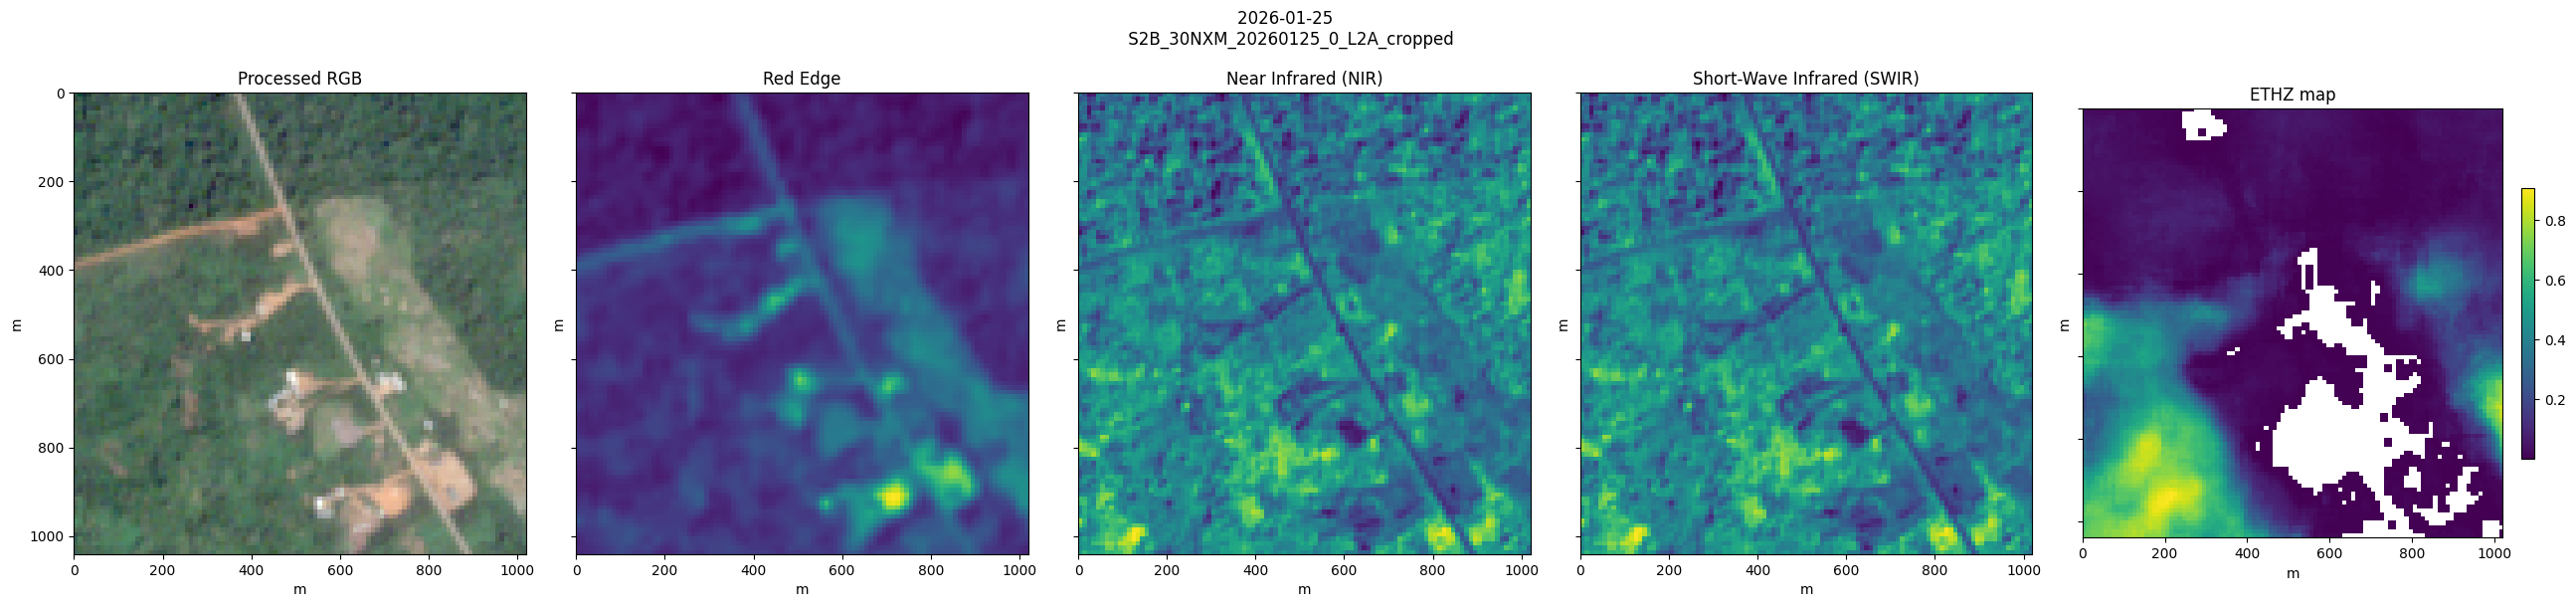

In [36]:
ss = s.sentinel_scenes[1]
ss.plot([(lon, lat) for lat, lon in s.lat_lons], padding_m=500, plot_scale=2.0)

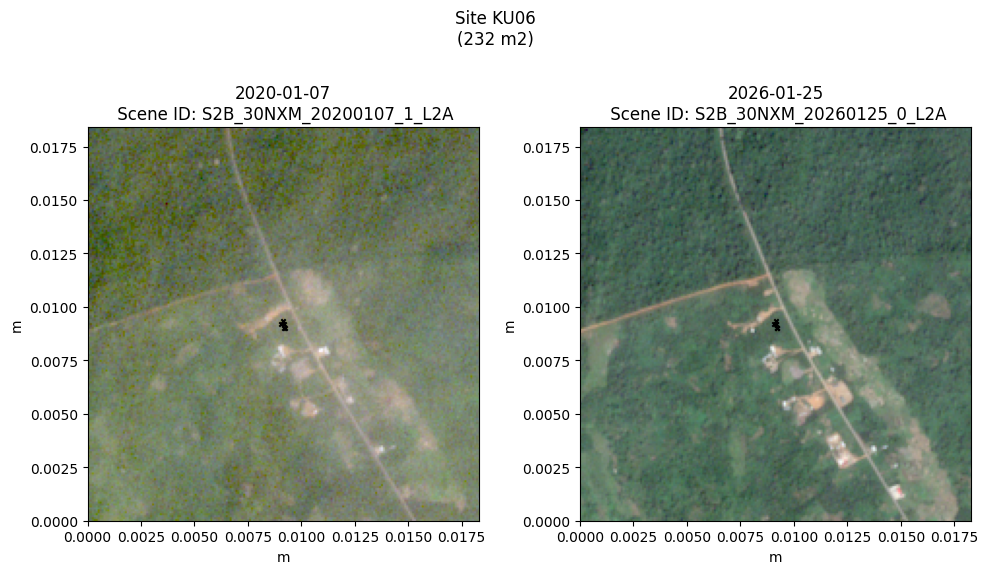

In [37]:
s.plot_over_scenes(padding_m=1000)

In [42]:
s.trees[0].lat_lon

(6.038196, -1.388036)